Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC3084 - Data Science  

Cristian Tunchez (231359)  
Nadissa Vela (23764)

# Laboratorio 2: Deep Learning

## Ejercicio 1 — Modelos LSTM para pronóstico de series de tiempo

Este notebook entrena redes **LSTM** (*Long Short-Term Memory*) sobre dos de las series mensuales construidas en el Laboratorio 1 y compara su desempeño contra los modelos clásicos (ARIMA, Holt-Winters, suavizamiento exponencial, *seasonal naive* y Prophet) que se ajustaron en dicho laboratorio.

Las dos series elegidas son:

| Clave | Serie | Mejor modelo del Laboratorio 1 |
|---|---|---|
| `total` | Total mensual de viajeros (serie obligatoria) | Prophet |
| `region_america_central` | Región: América del Centro | Prophet |

**Nota:** se usan *exactamente* los mismos conjuntos de entrenamiento y prueba del Laboratorio 1. No se vuelve a particionar nada.

## Configuración del entorno

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
from IPython.display import display

import data_utils as du
import lstm_utils as lu
import ts_utils as tsu   # copiado del Laboratorio 1: usa la misma definición de MAE/RMSE

# Semillas fijas para que el notebook sea reproducible.
SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4),
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
})
MILES = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")

print(f"PyTorch {torch.__version__} (CPU)")

PyTorch 2.13.0+cpu (CPU)


## 1. Las series y su partición

Se cargan las dos series desde `data/raw/series_mensuales.csv`, que es la salida del
notebook `02_preparacion_series.ipynb` del Laboratorio 1. Ese archivo ya trae la columna
`conjunto`, que marca qué meses son de entrenamiento y cuáles de prueba, así que basta con
respetarla.

In [2]:
SERIES = {
    "total": "Total mensual de viajeros",
    "region_america_central": "Región: América del Centro",
}

panel = du.cargar_panel()
datos = {}
for clave, etiqueta in SERIES.items():
    serie, train, test = du.cargar_serie(clave, panel)
    datos[clave] = {"serie": serie, "train": train, "test": test, "etiqueta": etiqueta}
    print(f"{etiqueta}")
    print(f"  Periodo completo: {serie.index.min():%Y-%m} a {serie.index.max():%Y-%m} ({len(serie)} meses)")
    print(f"  Entrenamiento:    {train.index.min():%Y-%m} a {train.index.max():%Y-%m} ({len(train)} meses)")
    print(f"  Prueba:           {test.index.min():%Y-%m} a {test.index.max():%Y-%m} ({len(test)} meses)")
    print(f"  Valor mínimo:     {serie.min():,.0f} viajeros\n")

Total mensual de viajeros
  Periodo completo: 2009-01 a 2026-06 (210 meses)
  Entrenamiento:    2009-01 a 2021-03 (147 meses)
  Prueba:           2021-04 a 2026-06 (63 meses)
  Valor mínimo:     9,779 viajeros

Región: América del Centro
  Periodo completo: 2009-01 a 2026-06 (210 meses)
  Entrenamiento:    2009-01 a 2021-03 (147 meses)
  Prueba:           2021-04 a 2026-06 (63 meses)
  Valor mínimo:     9,779 viajeros



Ambas series tienen 210 meses: **147 de entrenamiento** (enero 2009 a marzo 2021) y
**63 de prueba** (abril 2021 a junio 2026). Este es el punto que hay que tener presente
durante todo el laboratorio: el conjunto de prueba cubre la recuperación pospandemia, un
tramo que no se parece a casi nada de lo que el modelo ve durante el entrenamiento.

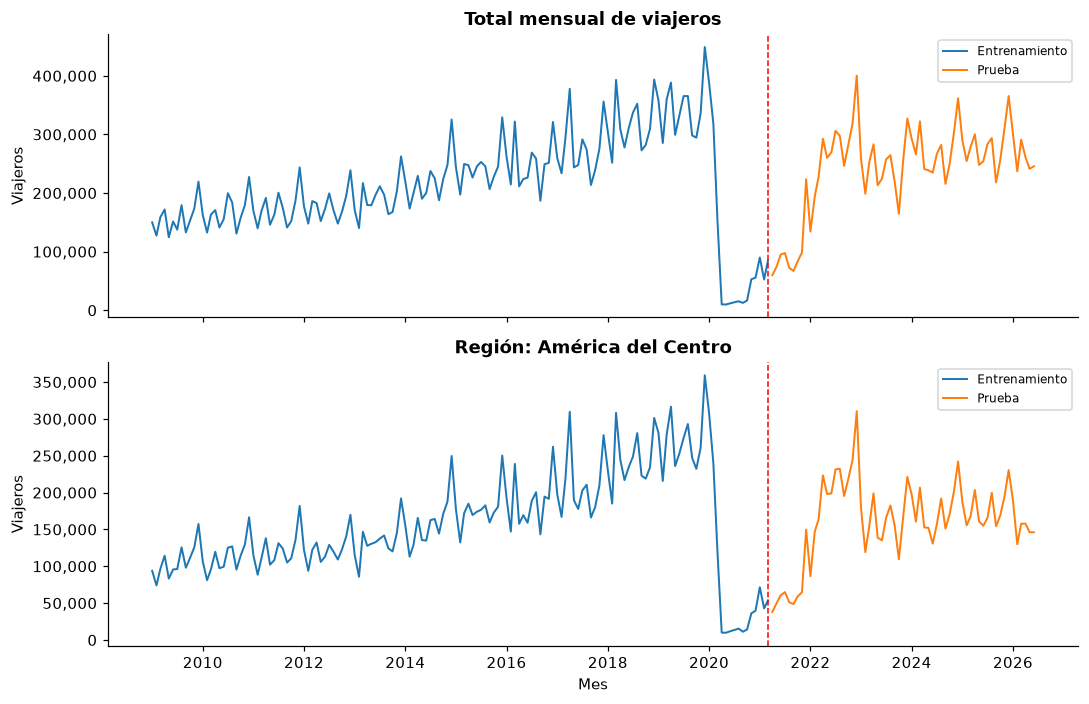

In [3]:
fig, ejes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
for eje, (clave, d) in zip(ejes, datos.items()):
    eje.plot(d["train"].index, d["train"].values, lw=1.3, color="C0", label="Entrenamiento")
    eje.plot(d["test"].index, d["test"].values, lw=1.3, color="C1", label="Prueba")
    eje.axvline(d["train"].index[-1], color="red", ls="--", lw=1)
    eje.set(title=d["etiqueta"], ylabel="Viajeros")
    eje.yaxis.set_major_formatter(MILES)
    eje.legend(fontsize=8)
ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

La línea roja marca el corte entre entrenamiento y prueba. Se ve el desplome de 2020 por
la pandemia y luego la recuperación, que ocurre casi por completo dentro del conjunto de
prueba.

## 2. Preparación de los datos para la LSTM

La red LSTM no recibe la serie tal cual. Hay cuatro pasos previos:

1. **Aplicar Logaritmo.** En el Laboratorio 1 estas dos series resultaron tener descomposición *multiplicativa* y por eso allí se modelaron en escala logarítmica. Aquí se mantiene el mismo criterio.

2. **Diferenciar.** Se trabaja con el cambio de un mes al siguiente en lugar del nivel. Esto quita la tendencia y evita que la red tenga que aprender a extrapolar valores cada vez más grandes.

3. **Estandarizar.** Las redes neuronales entrenan mejor con valores centrados en cero y de magnitud parecida. El escalador se ajusta **solo con los datos de entrenamiento** (si se ajustara con toda la serie, la media y la desviación ya incluirían información del futuro).

4. **Convertir a problema supervisado.** Se arma una "ventana" de 12 meses consecutivos como entrada y el mes número 13 como respuesta.

La clase `PreparadorSerie` de `src/lstm_utils.py` hace los cuatro pasos y guarda lo necesario para deshacerlos al final.

In [4]:
SEQ_LENGTH = 12   # una ventana de un año

preparadores = {}
for clave, d in datos.items():
    prep = lu.PreparadorSerie(d["serie"], n_train=len(d["train"]), seq_length=SEQ_LENGTH, log=True)
    preparadores[clave] = prep
    d["partes"] = prep.dividir(inicio_val="2018-01-01", fin_val="2019-12-01")
    p = d["partes"]
    print(f"{d['etiqueta']}")
    print(f"  Ajuste:      {p['x_ajuste'].shape[0]:3d} ventanas  "
          f"({prep.fechas_objetivo(p['pos_ajuste'])[0]:%Y-%m} a {prep.fechas_objetivo(p['pos_ajuste'])[-1]:%Y-%m})")
    print(f"  Validación:  {p['x_val'].shape[0]:3d} ventanas  "
          f"({prep.fechas_objetivo(p['pos_val'])[0]:%Y-%m} a {prep.fechas_objetivo(p['pos_val'])[-1]:%Y-%m})")
    print(f"  Prueba:      {p['x_test'].shape[0]:3d} ventanas  "
          f"({prep.fechas_objetivo(p['pos_test'])[0]:%Y-%m} a {prep.fechas_objetivo(p['pos_test'])[-1]:%Y-%m})")
    print(f"  Forma de x_ajuste: {p['x_ajuste'].shape}\n")

Total mensual de viajeros
  Ajuste:       95 ventanas  (2010-02 a 2017-12)
  Validación:   24 ventanas  (2018-01 a 2019-12)
  Prueba:       63 ventanas  (2021-04 a 2026-06)
  Forma de x_ajuste: (95, 12, 1)

Región: América del Centro
  Ajuste:       95 ventanas  (2010-02 a 2017-12)
  Validación:   24 ventanas  (2018-01 a 2019-12)
  Prueba:       63 ventanas  (2021-04 a 2026-06)
  Forma de x_ajuste: (95, 12, 1)



### ¿Por qué la validación va en 2018–2019 y no al final del entrenamiento?

Lo habitual sería dejar como validación los últimos meses del entrenamiento, pero en este caso, eso no
funcionaría. **Los últimos meses del entrenamiento son el desplome de la pandemia**, y ningún modelo entrenado con datos anteriores puede anticiparlo. Validar ahí no distingue un modelo bueno de uno malo; todos fallan igual.

La celda siguiente lo comprueba con un modelo de referencia trivial (predecir "el mes que viene será igual al anterior", es decir un cambio de cero) y una regresión lineal sobre los 12 rezagos.

In [5]:
from sklearn.linear_model import LinearRegression

prep = preparadores["total"]
x, y, pos = prep.ventanas()
fechas = prep.fechas_objetivo(pos)
en_train = pos < prep.n_dif_train

escenarios = {
    "Validación al final del entrenamiento (2019-01 a 2021-03)": en_train & (fechas >= "2019-01-01"),
    "Validación previa a la pandemia (2018-01 a 2019-12)": en_train & (fechas >= "2018-01-01") & (fechas <= "2019-12-01"),
}
for nombre, mascara in escenarios.items():
    ajuste = en_train & (fechas < fechas[mascara][0])
    modelo_lineal = LinearRegression().fit(
        x[ajuste].reshape(ajuste.sum(), -1), y[ajuste])
    mse_lineal = ((modelo_lineal.predict(x[mascara].reshape(mascara.sum(), -1)) - y[mascara]) ** 2).mean()
    mse_cero = (y[mascara] ** 2).mean()
    print(f"{nombre}")
    print(f"   MSE del modelo trivial (cambio cero): {mse_cero:.3f}")
    print(f"   MSE de una regresión sobre los 12 rezagos: {mse_lineal:.3f}   "
          f"-> {'aprende algo' if mse_lineal < mse_cero else 'PEOR que no hacer nada'}\n")

Validación al final del entrenamiento (2019-01 a 2021-03)
   MSE del modelo trivial (cambio cero): 3.720
   MSE de una regresión sobre los 12 rezagos: 20.648   -> PEOR que no hacer nada

Validación previa a la pandemia (2018-01 a 2019-12)
   MSE del modelo trivial (cambio cero): 0.328
   MSE de una regresión sobre los 12 rezagos: 0.082   -> aprende algo



El contraste es claro: con la ventana pandémica ni siquiera una regresión lineal logra mejorar al modelo trivial, mientras que con la ventana previa a la pandemia la reduce a una fracción. Por eso la validación se coloca en 2018–2019.

Los meses de entrenamiento posteriores a la validación (enero 2020 a marzo 2021) no se usan para elegir la configuración, pero **sí se usan al final**. Una vez elegida la mejor configuración, el modelo se reentrena con el conjunto de entrenamiento completo, para que llegue a la prueba habiendo visto la pandemia.

In [6]:
# Cómo se ve una ventana concreta: 12 valores de entrada y el valor que se quiere predecir.
p = datos["total"]["partes"]
print("Entrada (12 diferencias logarítmicas estandarizadas):")
print(np.round(p["x_ajuste"][0].ravel(), 3))
print(f"\nRespuesta esperada (mes 13): {p['y_ajuste'][0]:.3f}")
print(f"Mes que corresponde a esa respuesta: {preparadores['total'].fechas_objetivo(p['pos_ajuste'])[0]:%Y-%m}")

Entrada (12 diferencias logarítmicas estandarizadas):
[-0.49   0.689  0.257 -0.977  0.611 -0.282  0.824 -0.909  0.449  0.396
  0.732 -0.914]

Respuesta esperada (mes 13): -0.610
Mes que corresponde a esa respuesta: 2010-02


## 3. Dos configuraciones de LSTM

El enunciado pide al menos dos modelos con configuraciones distintas por serie. Se definen:

| | Modelo A | Modelo B |
|---|---|---|
| Capas LSTM | 1 | 2 apiladas |
| Neuronas por capa | 20 | 50 |
| Dropout | 0 | 0.2 |
| Tasa de aprendizaje | 0.01 | 0.01 |

El **Modelo A** es una red pequeña y simple. El **Modelo B** es más grande: al apilar dos
capas puede representar patrones más complejos, y el *dropout* apaga aleatoriamente parte de
las neuronas durante el entrenamiento para que no se memorice el conjunto de ajuste.

Los dos se entrenan con **error cuadrático medio** como pérdida, el optimizador **Adam** y
**detención temprana**: si la pérdida de validación deja de mejorar durante 40 épocas, el
entrenamiento se corta y se recuperan los pesos de la mejor época.

In [7]:
CONFIG_A = {"hidden_size": 20, "num_layers": 1, "dropout": 0.0, "lr": 0.01}
CONFIG_B = {"hidden_size": 50, "num_layers": 2, "dropout": 0.2, "lr": 0.01}


def construir(config, input_size=1, semilla=SEMILLA):
    torch.manual_seed(semilla)
    return lu.ModeloLSTM(input_size=input_size, hidden_size=config["hidden_size"],
                         num_layers=config["num_layers"], dropout=config["dropout"])


def entrenar_config(partes, config, semilla=SEMILLA, input_size=1):
    # Entrena con el tramo de ajuste y usa la validación previa a la pandemia
    # para la detención temprana.
    modelo = construir(config, input_size, semilla)
    historial = lu.entrenar(
        modelo, partes["x_ajuste"], partes["y_ajuste"], partes["x_val"], partes["y_val"],
        epocas=400, lr=config["lr"], batch_size=16, paciencia=40, semilla=semilla,
    )
    return modelo, historial

In [8]:
for clave, d in datos.items():
    print(f"=== {d['etiqueta']} ===")
    d["modelos_base"] = {}
    mse_cero = (d["partes"]["y_val"] ** 2).mean()
    print(f"  (referencia: MSE del modelo trivial en validación = {mse_cero:.3f})")
    for nombre, config in [("Modelo A", CONFIG_A), ("Modelo B", CONFIG_B)]:
        modelo, hist = entrenar_config(d["partes"], config)
        d["modelos_base"][nombre] = (modelo, hist)
        print(f"  {nombre}: {lu.contar_parametros(modelo):5,} parámetros | "
              f"{hist['epocas_corridas']:3d} épocas | "
              f"mejor MSE de validación = {hist['mejor_val']:.4f} (época {hist['mejor_epoca']})")
    print()

=== Total mensual de viajeros ===
  (referencia: MSE del modelo trivial en validación = 0.328)


  Modelo A: 1,861 parámetros |  89 épocas | mejor MSE de validación = 0.0861 (época 48)


  Modelo B: 31,051 parámetros |  71 épocas | mejor MSE de validación = 0.0536 (época 30)

=== Región: América del Centro ===
  (referencia: MSE del modelo trivial en validación = 0.397)


  Modelo A: 1,861 parámetros |  46 épocas | mejor MSE de validación = 0.1582 (época 5)


  Modelo B: 31,051 parámetros |  82 épocas | mejor MSE de validación = 0.0982 (época 41)



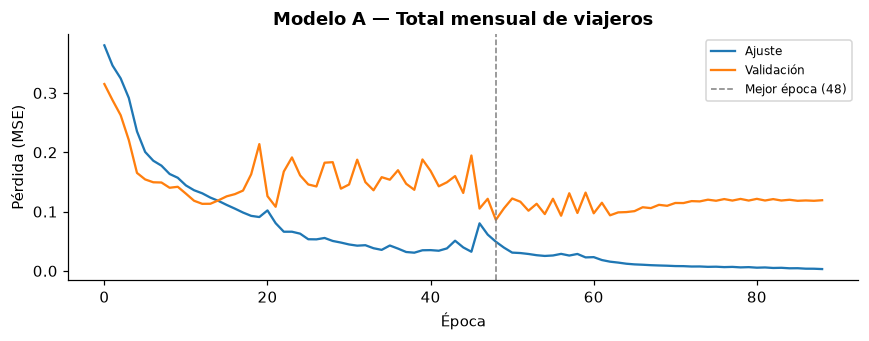

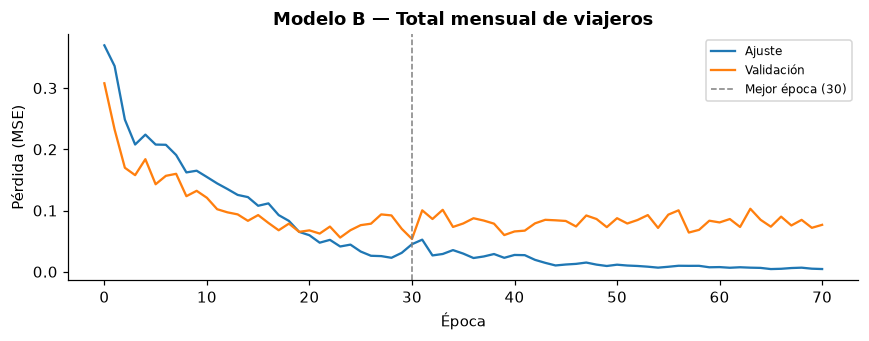

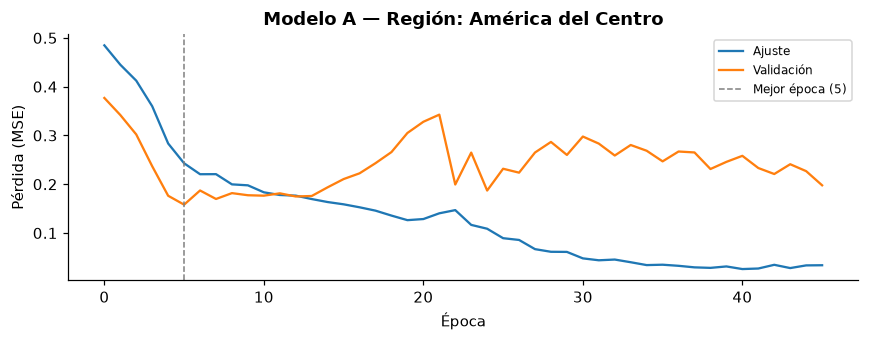

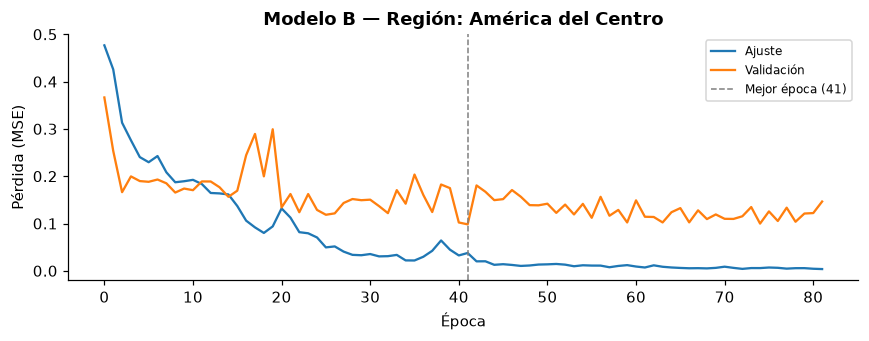

In [9]:
for clave, d in datos.items():
    for nombre, (modelo, hist) in d["modelos_base"].items():
        lu.graficar_perdidas(hist, f"{nombre} — {d['etiqueta']}")

En las curvas se observa lo típico de estos modelos: la pérdida de ajuste baja de forma sostenida, mientras que la de validación baja al principio y después se estanca o empieza a subir. La línea gris marca la época que la detención temprana eligió como mejor; a partir de ahí el modelo ya solo estaría memorizando el tramo de ajuste.

Nótese también la diferencia en número de parámetros. El Modelo B tiene bastantes más pesos que ajustar, con la misma cantidad de datos.

## 4. Tuneo de parámetros

Los dos modelos anteriores son un punto de partida. Para elegir mejor se prueba una rejilla de ocho combinaciones, variando el número de neuronas, la cantidad de capas y la tasa de aprendizaje.

**Criterio de selección:** No se usa el error a un paso, sino el **RMSE de un pronóstico recursivo de 24 meses sobre la validación**. El modelo arranca en diciembre de 2017 y predice todo 2018 y 2019 de corrido, alimentándose de sus propias predicciones. Se elige así porque es exactamente la tarea que después tendrá que resolver en el conjunto de prueba, y porque un modelo puede ser excelente prediciendo un mes y aun así desviarse sin control cuando encadena predicciones. El error se mide en viajeros para que el número sea
interpretable.

In [10]:
REJILLA = [
    {"hidden_size": 20,  "num_layers": 1, "dropout": 0.0, "lr": 0.01},
    {"hidden_size": 20,  "num_layers": 1, "dropout": 0.0, "lr": 0.001},
    {"hidden_size": 50,  "num_layers": 1, "dropout": 0.0, "lr": 0.01},
    {"hidden_size": 50,  "num_layers": 1, "dropout": 0.0, "lr": 0.001},
    {"hidden_size": 20,  "num_layers": 2, "dropout": 0.2, "lr": 0.01},
    {"hidden_size": 50,  "num_layers": 2, "dropout": 0.2, "lr": 0.01},
    {"hidden_size": 50,  "num_layers": 2, "dropout": 0.2, "lr": 0.001},
    {"hidden_size": 100, "num_layers": 1, "dropout": 0.0, "lr": 0.001},
]


def rmse_recursivo_validacion(modelo, prep, partes):
    # Pronóstico recursivo de los 24 meses de validación, en escala de viajeros.
    pos_inicio = partes["pos_val"][0]
    z_pred = lu.predecir_recursivo(modelo, prep.ventana_en(pos_inicio), len(partes["pos_val"]))
    pred = prep.revertir_recursivo(z_pred, pos_ancla=pos_inicio)
    real = prep.serie.values[partes["pos_val"] + 1]
    return tsu.evaluar(real, pred)["RMSE"]


for clave, d in datos.items():
    prep, partes = preparadores[clave], d["partes"]
    filas = []
    for config in REJILLA:
        modelo, hist = entrenar_config(partes, config)
        filas.append({
            "neuronas": config["hidden_size"], "capas": config["num_layers"],
            "dropout": config["dropout"], "lr": config["lr"],
            "mejor época": hist["mejor_epoca"],
            "MSE validación (un paso)": hist["mejor_val"],
            "RMSE validación recursiva (viajeros)": rmse_recursivo_validacion(modelo, prep, partes),
            "_config": config, "_epocas": hist["mejor_epoca"] + 1,
        })
    tabla = pd.DataFrame(filas).sort_values("RMSE validación recursiva (viajeros)").reset_index(drop=True)
    d["tabla_tuneo"] = tabla
    d["mejor_config"] = tabla.iloc[0]["_config"]
    d["mejor_epocas"] = int(tabla.iloc[0]["_epocas"])

    print(f"=== {d['etiqueta']} ===")
    display(tabla.drop(columns=["_config", "_epocas"]).style.format({
        "MSE validación (un paso)": "{:.4f}",
        "RMSE validación recursiva (viajeros)": "{:,.0f}",
        "lr": "{:.3f}", "dropout": "{:.1f}",
    }).hide(axis="index"))
    print(f"Configuración ganadora: {d['mejor_config']}  ->  {d['mejor_epocas']} épocas\n")

=== Total mensual de viajeros ===


neuronas,capas,dropout,lr,mejor época,MSE validación (un paso),RMSE validación recursiva (viajeros)
20,1,0.0,0.001,124,0.0824,"35,464"
50,2,0.2,0.001,143,0.0697,"37,622"
20,1,0.0,0.010,48,0.0861,"38,465"
50,2,0.2,0.010,30,0.0536,"39,958"
100,1,0.0,0.001,37,0.1073,"42,001"
50,1,0.0,0.001,73,0.1034,"44,092"
50,1,0.0,0.010,26,0.0725,"48,407"
20,2,0.2,0.010,19,0.0694,"48,944"


Configuración ganadora: {'hidden_size': 20, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001}  ->  125 épocas



=== Región: América del Centro ===


neuronas,capas,dropout,lr,mejor época,MSE validación (un paso),RMSE validación recursiva (viajeros)
20,1,0.0,0.001,105,0.0981,"28,061"
100,1,0.0,0.001,33,0.1340,"30,135"
50,2,0.2,0.010,41,0.0982,"30,507"
50,1,0.0,0.001,54,0.1185,"31,328"
50,2,0.2,0.001,47,0.1345,"32,991"
20,1,0.0,0.010,5,0.1582,"35,304"
50,1,0.0,0.010,26,0.1168,"56,425"
20,2,0.2,0.010,99,0.0925,"58,327"


Configuración ganadora: {'hidden_size': 20, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001}  ->  106 épocas



Las dos columnas de error no siempre ordenan igual, y eso es lo que esperamos. Hay configuraciones
que ganan en error a un paso pero se desvían al encadenar 24 predicciones. Como lo que interesa es pronosticar un horizonte largo, manda la columna recursiva.

### Reentrenamiento con todo el conjunto de entrenamiento

Ya elegida la configuración, se vuelve a entrenar desde cero usando **las 134 ventanas
completas del entrenamiento** (incluidos los meses de la pandemia), durante el número de
épocas que la validación indicó como óptimo. Así el modelo final llega al conjunto de prueba
habiendo visto todo lo que había disponible hasta marzo de 2021.

In [11]:
for clave, d in datos.items():
    partes = d["partes"]
    modelo = construir(d["mejor_config"])
    lu.entrenar(modelo, partes["x_train"], partes["y_train"], partes["x_val"], partes["y_val"],
                epocas=d["mejor_epocas"], lr=d["mejor_config"]["lr"], batch_size=16,
                paciencia=None, semilla=SEMILLA)
    d["mejor_modelo"] = modelo
    print(f"{d['etiqueta']}: reentrenado con {partes['x_train'].shape[0]} ventanas "
          f"durante {d['mejor_epocas']} épocas ({lu.contar_parametros(modelo):,} parámetros)")

Total mensual de viajeros: reentrenado con 134 ventanas durante 125 épocas (1,861 parámetros)


Región: América del Centro: reentrenado con 134 ventanas durante 106 épocas (1,861 parámetros)


## 5. Predicción sobre el conjunto de prueba

Hay dos formas de pedirle a la LSTM que prediga los 63 meses de prueba, y dan resultados muy distintos:

- **Un paso adelante.** Para predecir cada mes se le entregan los 12 meses reales anteriores. El modelo nunca se aleja de la realidad más de un mes.
- **Recursiva.** Se parte del último mes de entrenamiento y el modelo se alimenta con sus propias predicciones para seguir avanzando, 63 veces seguidas. Nunca vuelve a ver un dato real.

La distinción importa porque **ARIMA, Holt-Winters y Prophet del Laboratorio 1 pronosticaron de forma recursiva**. Por eso la comparación justa contra ellos es la recursiva, y es la que se utiliza para el criterio final. La predicción a un paso se reporta como referencia.

In [12]:
for clave, d in datos.items():
    prep, partes, modelo = preparadores[clave], d["partes"], d["mejor_modelo"]
    real = d["test"].values

    # (a) un paso adelante
    z_un_paso = lu.predecir(modelo, partes["x_test"])
    d["pred_un_paso"] = prep.revertir_un_paso(z_un_paso, partes["pos_test"])

    # (b) recursiva a 63 meses
    z_recursiva = lu.predecir_recursivo(modelo, prep.ventana_final_train(), pasos=len(real))
    d["pred_recursiva"] = prep.revertir_recursivo(z_recursiva)

    d["met_un_paso"] = tsu.evaluar(real, d["pred_un_paso"])
    d["met_recursiva"] = tsu.evaluar(real, d["pred_recursiva"])

    print(f"{d['etiqueta']}")
    print(f"  LSTM un paso adelante: MAE = {d['met_un_paso']['MAE']:>9,.0f}   RMSE = {d['met_un_paso']['RMSE']:>9,.0f}")
    print(f"  LSTM recursiva:        MAE = {d['met_recursiva']['MAE']:>9,.0f}   RMSE = {d['met_recursiva']['RMSE']:>9,.0f}\n")

Total mensual de viajeros
  LSTM un paso adelante: MAE =    40,895   RMSE =    55,206
  LSTM recursiva:        MAE =   126,226   RMSE =   152,698

Región: América del Centro
  LSTM un paso adelante: MAE =    31,605   RMSE =    42,642
  LSTM recursiva:        MAE =    94,799   RMSE =   112,580



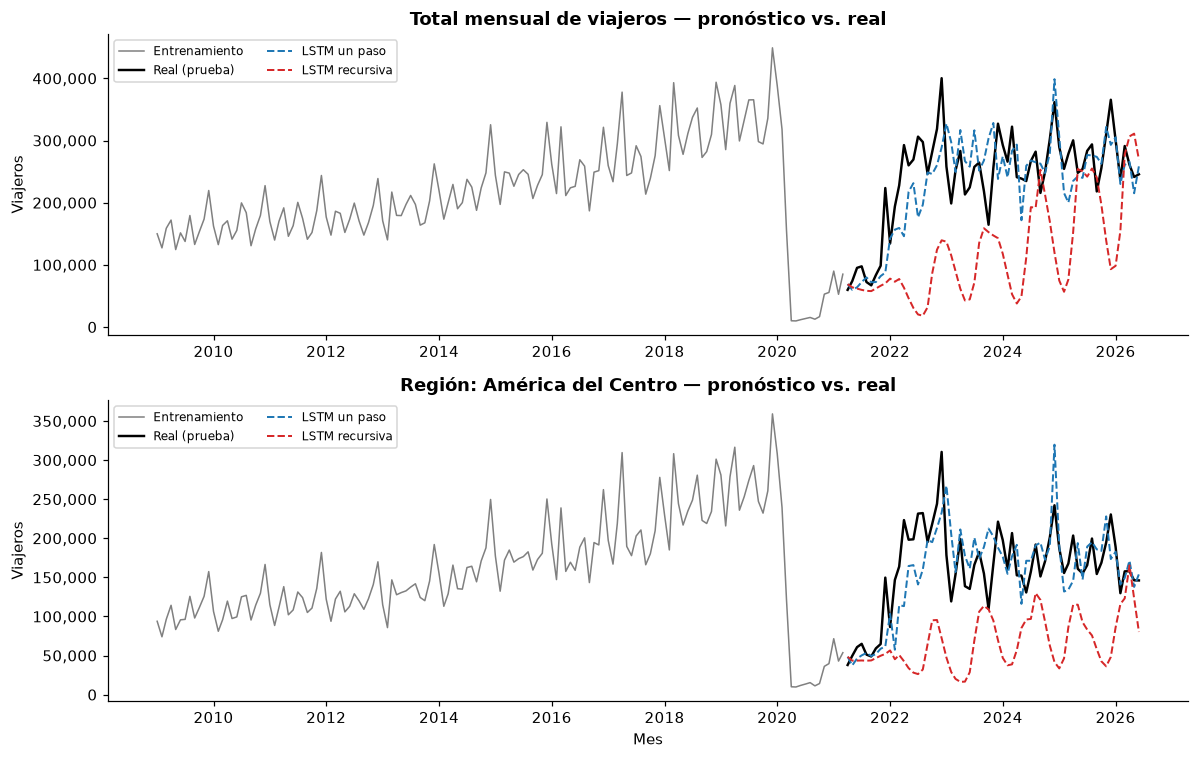

In [13]:
fig, ejes = plt.subplots(2, 1, figsize=(11, 7))
for eje, (clave, d) in zip(ejes, datos.items()):
    eje.plot(d["train"].index, d["train"].values, color="grey", lw=1, label="Entrenamiento")
    eje.plot(d["test"].index, d["test"].values, color="black", lw=1.6, label="Real (prueba)")
    eje.plot(d["test"].index, d["pred_un_paso"], color="C0", ls="--", lw=1.3, label="LSTM un paso")
    eje.plot(d["test"].index, d["pred_recursiva"], color="C3", ls="--", lw=1.3, label="LSTM recursiva")
    eje.set(title=f"{d['etiqueta']} — pronóstico vs. real", ylabel="Viajeros")
    eje.yaxis.set_major_formatter(MILES)
    eje.legend(fontsize=8, ncol=2)
ejes[-1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

Como se mencionaba, la diferencia entre las dos curvas punteadas es: la predicción a un paso sigue de cerca la serie real porque se reajusta cada mes con datos verdaderos, mientras que la recursiva dibuja una trayectoria que solo depende de lo aprendido en el entrenamiento y que se va separando de la realidad conforme avanza el horizonte.

## 6. Comparación contra los modelos del Laboratorio 1

Se cargan las métricas que produjeron los modelos clásicos en el laboratorio anterior sobre
**el mismo conjunto de prueba**.

In [14]:
resumen_total = pd.read_csv("../data/raw/resumen_total.csv")
resumen_regiones = pd.read_csv("../data/raw/resumen_regiones.csv")

print("Laboratorio 1 — serie Total, todos los modelos:")
display(resumen_total.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}",
                                    "AIC": "{:,.1f}", "BIC": "{:,.1f}"}, na_rep="—").hide(axis="index"))

fila_ac = resumen_regiones[resumen_regiones["región"] == "América del Centro"].iloc[0]
BASELINE = {
    "total": {"modelo": resumen_total.iloc[0]["modelo"],
              "MAE": resumen_total.iloc[0]["MAE"], "RMSE": resumen_total.iloc[0]["RMSE"]},
    "region_america_central": {"modelo": fila_ac["mejor_modelo"],
                               "MAE": fila_ac["MAE"], "RMSE": fila_ac["RMSE"]},
}
print("\nMejor modelo del Laboratorio 1 por serie:")
for clave, b in BASELINE.items():
    print(f"  {SERIES[clave]:32} {b['modelo']:12} MAE = {b['MAE']:>10,.0f}   RMSE = {b['RMSE']:>10,.0f}")

Laboratorio 1 — serie Total, todos los modelos:


modelo,MAE,RMSE,AIC,BIC
Prophet,"132,304","139,549",—,—
Holt-Winters,"134,375","146,606","3,081.2","3,129.0"
Suavizamiento exp. simple,"165,373","180,598","3,177.2","3,183.2"
Seasonal naive,"207,322","219,664",—,—
"ARIMA (1, 1, 0)x(1, 1, 0, 12)","226,659","243,072",63.9,72.6



Mejor modelo del Laboratorio 1 por serie:
  Total mensual de viajeros        Prophet      MAE =    132,304   RMSE =    139,549
  Región: América del Centro       Prophet      MAE =     62,485   RMSE =     67,838


In [15]:
filas = []
for clave, d in datos.items():
    b, nivel = BASELINE[clave], d["test"].mean()
    filas.append({"serie": d["etiqueta"], "modelo": f"Lab 1 — {b['modelo']}",
                  "horizonte": "63 meses (recursivo)",
                  "MAE": b["MAE"], "RMSE": b["RMSE"], "MAE / nivel medio": b["MAE"] / nivel})
    filas.append({"serie": d["etiqueta"], "modelo": "Lab 2 — LSTM",
                  "horizonte": "63 meses (recursivo)",
                  "MAE": d["met_recursiva"]["MAE"], "RMSE": d["met_recursiva"]["RMSE"],
                  "MAE / nivel medio": d["met_recursiva"]["MAE"] / nivel})
    filas.append({"serie": d["etiqueta"], "modelo": "Lab 2 — LSTM (referencia)",
                  "horizonte": "1 mes adelante",
                  "MAE": d["met_un_paso"]["MAE"], "RMSE": d["met_un_paso"]["RMSE"],
                  "MAE / nivel medio": d["met_un_paso"]["MAE"] / nivel})

comparacion = pd.DataFrame(filas)
display(comparacion.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}",
                                  "MAE / nivel medio": "{:.1%}"}).hide(axis="index"))
comparacion.to_csv("../data/processed/comparacion_lab1_lab2.csv", index=False)
print("Guardado: data/processed/comparacion_lab1_lab2.csv")

serie,modelo,horizonte,MAE,RMSE,MAE / nivel medio
Total mensual de viajeros,Lab 1 — Prophet,63 meses (recursivo),"132,304","139,549",54.8%
Total mensual de viajeros,Lab 2 — LSTM,63 meses (recursivo),"126,226","152,698",52.2%
Total mensual de viajeros,Lab 2 — LSTM (referencia),1 mes adelante,"40,895","55,206",16.9%
Región: América del Centro,Lab 1 — Prophet,63 meses (recursivo),"62,485","67,838",38.8%
Región: América del Centro,Lab 2 — LSTM,63 meses (recursivo),"94,799","112,580",58.9%
Región: América del Centro,Lab 2 — LSTM (referencia),1 mes adelante,"31,605","42,642",19.6%


Guardado: data/processed/comparacion_lab1_lab2.csv


In [16]:
# Veredicto por serie: la comparación válida es recursivo contra recursivo.
for clave, d in datos.items():
    b = BASELINE[clave]
    print(f"{d['etiqueta']}")
    for metrica in ["MAE", "RMSE"]:
        lstm, lab1 = d["met_recursiva"][metrica], b[metrica]
        dif = (lstm - lab1) / lab1 * 100
        print(f"  {metrica:4}: LSTM = {lstm:>10,.0f}   {b['modelo']} = {lab1:>10,.0f}   "
              f"-> la LSTM tiene {abs(dif):5.1f}% {'menos' if dif < 0 else 'más '} error")
    gana_mae = d["met_recursiva"]["MAE"] < b["MAE"]
    gana_rmse = d["met_recursiva"]["RMSE"] < b["RMSE"]
    if gana_mae and gana_rmse:
        print("  Veredicto: gana la LSTM en las dos métricas.\n")
    elif not gana_mae and not gana_rmse:
        print(f"  Veredicto: gana {b['modelo']} (Lab 1) en las dos métricas.\n")
    else:
        print("  Veredicto: resultado mixto. La LSTM gana en "
              f"{'MAE' if gana_mae else 'RMSE'} y pierde en {'RMSE' if gana_mae else 'MAE'}.")
        print("             Un MAE menor con un RMSE mayor significa que la LSTM suele quedar\n"
              "             más cerca del valor real, pero comete algunos errores muy grandes,\n"
              "             que el RMSE penaliza más que el MAE.\n")

Total mensual de viajeros
  MAE : LSTM =    126,226   Prophet =    132,304   -> la LSTM tiene   4.6% menos error
  RMSE: LSTM =    152,698   Prophet =    139,549   -> la LSTM tiene   9.4% más  error
  Veredicto: resultado mixto. La LSTM gana en MAE y pierde en RMSE.
             Un MAE menor con un RMSE mayor significa que la LSTM suele quedar
             más cerca del valor real, pero comete algunos errores muy grandes,
             que el RMSE penaliza más que el MAE.

Región: América del Centro
  MAE : LSTM =     94,799   Prophet =     62,485   -> la LSTM tiene  51.7% más  error
  RMSE: LSTM =    112,580   Prophet =     67,838   -> la LSTM tiene  66.0% más  error
  Veredicto: gana Prophet (Lab 1) en las dos métricas.



## 7. Respuestas al inciso 1.4

**¿Cuál predijo mejor entre los modelos LSTM?**

En las dos series gana la misma configuración: **una sola capa con 20 neuronas y tasa de
aprendizaje 0.001**. De las tablas de la sección 4 salen dos lecturas:

1. **La red más pequeña gana en ambas series.** El Modelo A tiene 1,861 pesos y el Modelo B
   31,051, pero solo hay 95 ventanas de ajuste. La red grande tiene muchísimos más
   parámetros que datos para ajustarlos, así que aprende bien el tramo de ajuste y
   generaliza peor.
2. **Las dos columnas de error ordenan distinto, y eso cambia la elección.** El caso más
   claro es América del Centro, la configuración con el mejor error a un paso (2 capas, 20
   neuronas) es la **peor de las ocho** en modo recursivo. Si se hubiera elegido por error a
   un paso se habría escogido justamente el modelo que más se desvía al encadenar
   predicciones.

**¿Son mejores que los modelos del Laboratorio 1?**

En el horizonte que importa (los 63 meses de prueba pronosticados de corrido) **no**. Pero...

- En **América del Centro** Prophet gana con claridad en las dos métricas.
- En la serie **Total** el resultado es mixto. La LSTM logra menor MAE que Prophet pero mayor
  RMSE. Eso significa que la LSTM suele quedar más cerca del valor real mes a mes, pero
  comete algunos errores muy grandes, y el RMSE los castiga más. Como criterio de desempate
  se toma el RMSE, que es el que usó el Laboratorio 1 para elegir al modelo ganador, así que
  también aquí se declara mejor a Prophet.

El resultado es coherente con lo que se esperaba. 147 meses de entrenamiento son muy pocos datos para una red neuronal, mientras que Prophet incorpora de fábrica la estructura que estas series tienen (tendencia por tramos más estacionalidad anual) y por eso rinde bien con muestras pequeñas.

Sí conviene notar la otra fila de la tabla. **A un mes de horizonte la LSTM es mucho más precisa** que cualquier modelo del Laboratorio 1; su MAE relativo baja de 54.8 % a 16.9 % en la serie total. No es una comparación válida para el veredicto (la LSTM está viendo datos reales que Prophet nunca vio), pero sí dice algo útil: si el objetivo fuera un pronóstico operativo mes a mes, actualizado con la información más reciente, la LSTM sería la herramienta adecuada. Para un pronóstico de años, no.

**¿Cómo se determinó?**

Con cuatro criterios explícitos:

1. **Mismo conjunto de prueba.** Los 63 meses de abril 2021 a junio 2026, sin reparticionar.
2. **Mismas métricas.** MAE y RMSE calculados con `ts_utils.evaluar()`, el mismo código del
   Laboratorio 1. Se añade el MAE relativo al nivel medio de la prueba para poder comparar
   entre series de distinta magnitud.
3. **Mismo horizonte de pronóstico.** Los modelos clásicos pronostican los 63 meses de una
   sola vez, así que la LSTM se evalúa igual, en modo recursivo. Comparar la LSTM a un paso
   contra Prophet a 63 pasos le daría a la LSTM una ventaja artificial.
4. **Selección sin mirar la prueba.** La configuración se eligió con la validación de
   2018–2019, y el conjunto de prueba solo se usó una vez, al final.

**Un detalle sobre la magnitud de los errores:** todos los errores son grandes en relación con
el nivel de las series, y la razón es el conjunto de prueba, no los modelos. El entrenamiento
termina en marzo 2021, con la serie hundida por la pandemia, y la prueba cubre justamente la
recuperación. Ningún modelo entrenado solo con datos hasta marzo 2021 tenía cómo anticipar la
magnitud de ese rebote. Esto afecta por igual a los modelos del Laboratorio 1 y a las LSTM,
por lo que la comparación entre ellos sigue siendo válida.

In [17]:
# Se guardan los insumos que necesita el notebook 03 (inciso 2.14).
import json
config_ganadora = {clave: {"config": d["mejor_config"], "epocas": d["mejor_epocas"],
                           "rmse_un_paso": d["met_un_paso"]["RMSE"],
                           "mae_un_paso": d["met_un_paso"]["MAE"],
                           "rmse_recursiva": d["met_recursiva"]["RMSE"],
                           "mae_recursiva": d["met_recursiva"]["MAE"]}
                   for clave, d in datos.items()}
with open("../data/processed/mejor_config_lstm.json", "w", encoding="utf-8") as f:
    json.dump(config_ganadora, f, indent=2, ensure_ascii=False)
print("Guardado: data/processed/mejor_config_lstm.json")
print(json.dumps(config_ganadora, indent=2, ensure_ascii=False))

Guardado: data/processed/mejor_config_lstm.json
{
  "total": {
    "config": {
      "hidden_size": 20,
      "num_layers": 1,
      "dropout": 0.0,
      "lr": 0.001
    },
    "epocas": 125,
    "rmse_un_paso": 55206.48680079801,
    "mae_un_paso": 40894.906688325005,
    "rmse_recursiva": 152697.61699692186,
    "mae_recursiva": 126226.13570688783
  },
  "region_america_central": {
    "config": {
      "hidden_size": 20,
      "num_layers": 1,
      "dropout": 0.0,
      "lr": 0.001
    },
    "epocas": 106,
    "rmse_un_paso": 42641.83034727392,
    "mae_un_paso": 31605.06747146653,
    "rmse_recursiva": 112580.13867423491,
    "mae_recursiva": 94798.86686344942
  }
}
